<a href="https://colab.research.google.com/github/joolsa/PersonaBase/blob/main/Notebooks/PD01a_NMF_illustration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YouTube Audience Persona Generation using Non-negative Matrix Factorization (NMF)

This notebook demonstrates how to use Non-negative Matrix Factorization (NMF) to discover hidden patterns in YouTube audience behavior and create meaningful personas for content strategy. NMF is particularly well-suited for this task because it naturally handles non-negative data (like viewing times) and produces interpretable results.

## Table of Contents
1. [Introduction and Setup](#introduction)
2. [Data Generation](#data-generation)
3. [Exploratory Data Analysis](#eda)
4. [Data Preprocessing](#preprocessing)
5. [Optimal Components Selection](#components)
6. [NMF Model Application](#nmf-application)
7. [Persona Analysis](#analysis)
8. [Visualization](#visualization)
9. [Validation](#validation)
10. [Actionable Personas](#actionable)
11. [Summary](#summary)



<a name="introduction"></a>

## 1. Introduction and Setup


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style for better visualization
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)  # For reproducible results

print("YouTube Audience Persona Generation using NMF")
print("=" * 50)

YouTube Audience Persona Generation using NMF


### What is Non-negative Matrix Factorization (NMF)?

NMF is a dimensionality reduction technique that factorizes a non-negative matrix into two smaller non-negative matrices. For audience segmentation:

- **Input Matrix (V)**: Demographics × Content Categories (viewing times)
- **Output Matrices**:
  - **W**: Demographics × Personas (how much each demographic belongs to each persona)
  - **H**: Personas × Content Categories (content preferences for each persona)

The key advantage is interpretability - both matrices contain only positive values, making them easy to understand as "membership strengths" and "preference scores."

<a name="data-generation"></a>

## 2. Data Generation

### Generate Realistic YouTube Audience Data

Since we're demonstrating the technique, we'll create synthetic but realistic data that mimics real YouTube viewing patterns.

In [ ]:
def generate_youtube_audience_data():
    """
    Generate synthetic but realistic YouTube audience viewing data.

    This function creates a dataset that simulates how different demographic groups
    engage with various types of YouTube content. The data includes viewing patterns
    that reflect real-world behaviors and preferences.

    Returns:
    - DataFrame with demographic groups as rows and content categories as columns
    - Values represent average viewing time in minutes per video
    """

    # Define demographic segments - these represent our audience groups
    demographics = [
        'Gen_Z_Urban_Male', 'Gen_Z_Urban_Female', 'Gen_Z_Rural_Male', 'Gen_Z_Rural_Female',
        'Millennial_Urban_Male', 'Millennial_Urban_Female', 'Millennial_Rural_Male', 'Millennial_Rural_Female',
        'Gen_X_Urban_Male', 'Gen_X_Urban_Female', 'Gen_X_Rural_Male', 'Gen_X_Rural_Female',
        'Boomer_Urban_Male', 'Boomer_Urban_Female', 'Boomer_Rural_Male', 'Boomer_Rural_Female'
    ]

    # Define content categories - these represent different types of YouTube content
    content_categories = [
        'Gaming_Streams', 'Tech_Reviews', 'Beauty_Fashion', 'Cooking_Food',
        'Fitness_Health', 'Music_Entertainment', 'News_Politics', 'Travel_Vlogs',
        'DIY_Crafts', 'Education_Tutorials', 'Comedy_Sketches', 'Sports_Highlights',
        'Pet_Animals', 'Business_Finance', 'Art_Design', 'Parenting_Family'
    ]

    # Create base viewing patterns with realistic demographic preferences
    np.random.seed(42)
    n_demographics = len(demographics)
    n_content = len(content_categories)

    # Initialize the data matrix
    data = np.zeros((n_demographics, n_content))

    # Define realistic viewing patterns for different demographic groups
    # Each group has different preferences based on age, gender, and location

    for i, demo in enumerate(demographics):
        age_group = demo.split('_')[0]
        location = demo.split('_')[1]
        gender = demo.split('_')[2]

        # Base viewing time (minutes) - younger audiences watch more
        if age_group == 'Gen':  # Gen Z
            base_time = np.random.normal(8, 2)
        elif age_group == 'Millennial':
            base_time = np.random.normal(6, 1.5)
        elif age_group == 'Gen' and 'X' in demo:  # Gen X
            base_time = np.random.normal(4, 1)
        else:  # Boomers
            base_time = np.random.normal(3, 1)

        # Apply content preferences based on demographics
        for j, content in enumerate(content_categories):

            # Start with base viewing time
            view_time = base_time

            # Age-based preferences
            if age_group == 'Gen' and content in ['Gaming_Streams', 'Music_Entertainment', 'Comedy_Sketches']:
                view_time *= np.random.uniform(1.5, 2.5)  # Gen Z loves gaming and entertainment
            elif age_group == 'Millennial' and content in ['Tech_Reviews', 'Business_Finance', 'Fitness_Health']:
                view_time *= np.random.uniform(1.3, 2.0)  # Millennials focus on career and health
            elif 'X' in demo and content in ['News_Politics', 'Parenting_Family', 'DIY_Crafts']:
                view_time *= np.random.uniform(1.2, 1.8)  # Gen X interested in family and current events
            elif age_group == 'Boomer' and content in ['News_Politics', 'Cooking_Food', 'Travel_Vlogs']:
                view_time *= np.random.uniform(1.1, 1.6)  # Boomers prefer traditional content

            # Gender-based preferences
            if gender == 'Female' and content in ['Beauty_Fashion', 'Cooking_Food', 'DIY_Crafts', 'Parenting_Family']:
                view_time *= np.random.uniform(1.2, 1.8)
            elif gender == 'Male' and content in ['Gaming_Streams', 'Sports_Highlights', 'Tech_Reviews']:
                view_time *= np.random.uniform(1.2, 1.8)

            # Location-based preferences
            if location == 'Urban' and content in ['Tech_Reviews', 'Business_Finance', 'Art_Design']:
                view_time *= np.random.uniform(1.1, 1.4)
            elif location == 'Rural' and content in ['DIY_Crafts', 'Cooking_Food', 'Pet_Animals']:
                view_time *= np.random.uniform(1.1, 1.4)

            # Add some random noise to make it more realistic
            view_time *= np.random.uniform(0.8, 1.2)

            # Ensure minimum viewing time (some content might not appeal at all)
            view_time = max(0.1, view_time)

            data[i, j] = view_time

    # Create DataFrame
    df = pd.DataFrame(data, index=demographics, columns=content_categories)

    return df

## Generating the dataset

In [ ]:
# Generate the dataset
print("\n1. GENERATING SYNTHETIC YOUTUBE AUDIENCE DATA")
print("-" * 45)

youtube_data = generate_youtube_audience_data()
print(f"Dataset shape: {youtube_data.shape}")
print(f"Demographics (rows): {youtube_data.shape[0]}")
print(f"Content categories (columns): {youtube_data.shape[1]}")
print("\nFirst 5 rows of the dataset:")
display(youtube_data.head())


1. GENERATING SYNTHETIC YOUTUBE AUDIENCE DATA
---------------------------------------------
Dataset shape: (16, 16)
Demographics (rows): 16
Content categories (columns): 16

First 5 rows of the dataset:


,Gaming_Streams,Tech_Reviews,Beauty_Fashion,Cooking_Food,Fitness_Health,Music_Entertainment,News_Politics,Travel_Vlogs,DIY_Crafts,Education_Tutorials,Comedy_Sketches,Sports_Highlights,Pet_Animals,Business_Finance,Art_Design,Parenting_Family
Gen_Z_Urban_Male,20.865437,7.756000,7.755913,7.403691,10.310700,20.468942,7.268793,10.683869,10.189348,7.958605,13.209922,8.289215,9.082486,8.748609,8.242402,9.395805
Gen_Z_Urban_Female,11.609790,7.310611,7.587755,8.604491,6.795647,16.131955,6.322280,8.055719,6.705592,6.379747,22.436664,8.676231,7.119847,6.480524,8.292639,7.538579
Gen_Z_Rural_Male,14.236687,7.203706,8.491322,7.372514,8.037007,14.261360,9.470606,8.850460,9.374657,9.232190,19.549171,6.660625,7.003433,6.522643,7.415949,7.617975
Gen_Z_Rural_Female,11.794299,5.547400,5.368935,5.985078,5.039374,11.241955,7.030628,6.525396,5.175406,4.720661,14.752929,6.423622,6.523103,4.881951,5.551430,4.980399
Millennial_Urban_Male,7.499929,19.140995,7.503167,6.424688,9.756674,7.174612,6.656140,7.201073,6.480771,6.555972,6.308592,6.657026,5.279193,13.590167,8.021420,6.264002


<a name="eda"></a>
## 3. Exploratory Data Analysis

Understanding our data is crucial before applying NMF. Let's examine the viewing patterns and identify initial trends.

In [ ]:
print("2. EXPLORATORY DATA ANALYSIS")
print("-" * 35)

# Basic statistics
print("Dataset Statistics:")
print(f"Mean viewing time across all demographics and content: {youtube_data.values.mean():.2f} minutes")
print(f"Standard deviation: {youtube_data.values.std():.2f} minutes")
print(f"Minimum viewing time: {youtube_data.values.min():.2f} minutes")
print(f"Maximum viewing time: {youtube_data.values.max():.2f} minutes")

2. EXPLORATORY DATA ANALYSIS
-----------------------------------
Dataset Statistics:
Mean viewing time across all demographics and content: 8.86 minutes
Standard deviation: 5.14 minutes
Minimum viewing time: 2.24 minutes
Maximum viewing time: 35.31 minutes


### Identifying the most and least popular content

In [ ]:
# Most and least popular content overall
content_popularity = youtube_data.mean(axis=0).sort_values(ascending=False)
print(f"Most popular content categories:")
for i, (content, avg_time) in enumerate(content_popularity.head().items()):
    print(f"{i+1}. {content}: {avg_time:.2f} minutes average")

print(f"\nLeast popular content categories:")
for i, (content, avg_time) in enumerate(content_popularity.tail().items()):
    print(f"{i+1}. {content}: {avg_time:.2f} minutes average")

Most popular content categories:
1. Comedy_Sketches: 12.42 minutes average
2. Gaming_Streams: 12.31 minutes average
3. Music_Entertainment: 11.45 minutes average
4. DIY_Crafts: 9.32 minutes average
5. News_Politics: 9.24 minutes average

Least popular content categories:
1. Sports_Highlights: 7.62 minutes average
2. Beauty_Fashion: 7.59 minutes average
3. Art_Design: 7.28 minutes average
4. Pet_Animals: 7.17 minutes average
5. Education_Tutorials: 6.88 minutes average


## Demographic distributions

In [ ]:
# Demographic analysis
demographic_engagement = youtube_data.mean(axis=1).sort_values(ascending=False)
print(f"Most engaged demographic groups:")
for i, (demo, avg_time) in enumerate(demographic_engagement.head().items()):
    print(f"{i+1}. {demo}: {avg_time:.2f} minutes average")

Most engaged demographic groups:
1. Gen_X_Rural_Female: 18.90 minutes average
2. Gen_X_Urban_Female: 13.85 minutes average
3. Gen_X_Urban_Male: 10.63 minutes average
4. Gen_Z_Urban_Male: 10.48 minutes average
5. Gen_X_Rural_Male: 10.19 minutes average


### Initial Data Visualization


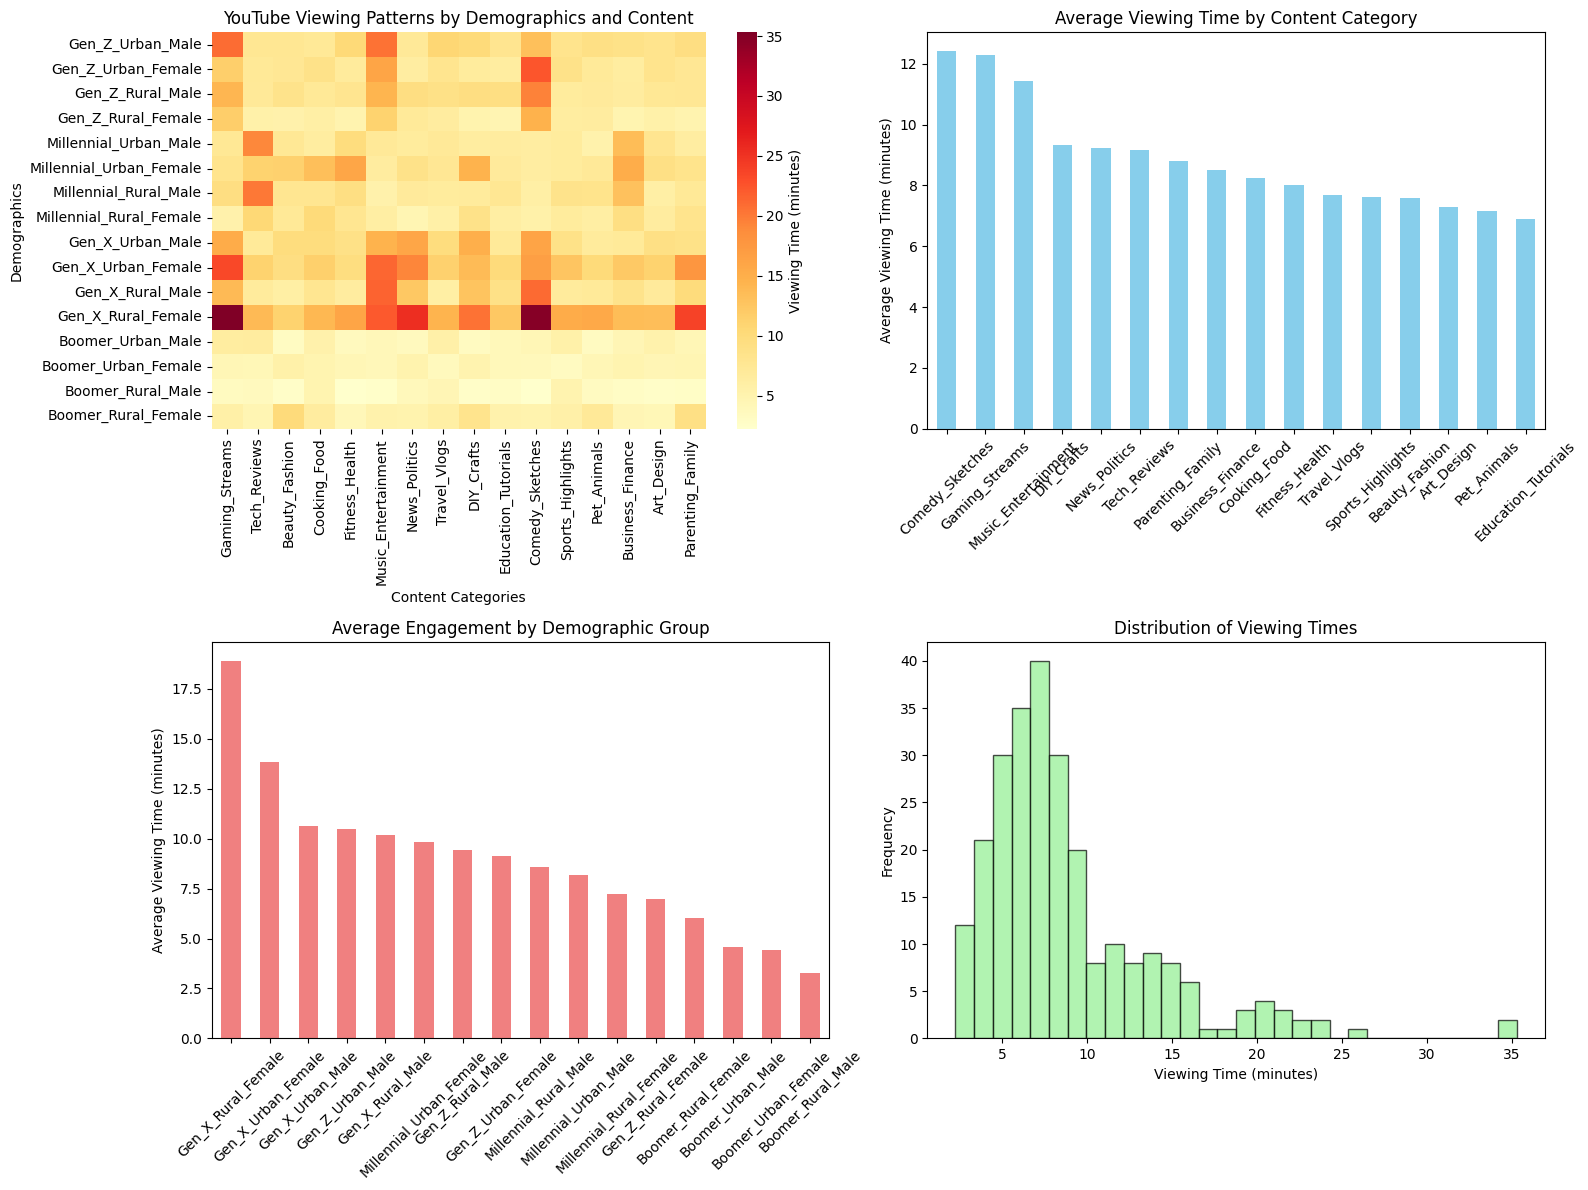

In [ ]:
# Create initial exploratory plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap of all viewing data
sns.heatmap(youtube_data, cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Viewing Time (minutes)'})
ax1.set_title('YouTube Viewing Patterns by Demographics and Content')
ax1.set_xlabel('Content Categories')
ax1.set_ylabel('Demographics')

# 2. Content popularity
content_popularity.plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Average Viewing Time by Content Category')
ax2.set_ylabel('Average Viewing Time (minutes)')
ax2.tick_params(axis='x', rotation=45)

# 3. Demographic engagement
demographic_engagement.plot(kind='bar', ax=ax3, color='lightcoral')
ax3.set_title('Average Engagement by Demographic Group')
ax3.set_ylabel('Average Viewing Time (minutes)')
ax3.tick_params(axis='x', rotation=45)

# 4. Distribution of viewing times
ax4.hist(youtube_data.values.flatten(), bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
ax4.set_title('Distribution of Viewing Times')
ax4.set_xlabel('Viewing Time (minutes)')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<a name="preprocessing"></a>
## 4. Data Preprocessing for NMF

NMF requires non-negative data (which we already have) and benefits from normalization to ensure all features are on similar scales.
:

In [ ]:
print("3. DATA PREPROCESSING FOR NMF")
print("-" * 35)

# NMF requires non-negative data, which we already have (viewing times are positive)
# However, we should normalize the data to ensure features are on similar scales

# Create a copy of the original data for preprocessing
data_for_nmf = youtube_data.copy()

print("Original data range:")
print(f"Min: {data_for_nmf.values.min():.2f}, Max: {data_for_nmf.values.max():.2f}")

# Method 1: Min-Max scaling to [0,1] range (preserves non-negativity)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_for_nmf)
data_scaled_df = pd.DataFrame(data_scaled,
                             index=data_for_nmf.index,
                             columns=data_for_nmf.columns)

print("After Min-Max scaling:")
print(f"Min: {data_scaled.min():.2f}, Max: {data_scaled.max():.2f}")

3. DATA PREPROCESSING FOR NMF
-----------------------------------
Original data range:
Min: 2.24, Max: 35.31
After Min-Max scaling:
Min: 0.00, Max: 1.00


### Why Min-Max Scaling for NMF?

- **Preserves non-negativity**: Essential for NMF algorithm
- **Equal feature importance**: Prevents features with larger scales from dominating
- **Interpretability**: Scaled values represent relative preferences within each content category


<a name="components"></a>

## 5. Determining Optimal Number of Components

One of the key decisions in NMF is choosing the number of personas (components). We'll use reconstruction error and explained variance to guide this decision.

In [ ]:
def evaluate_nmf_components(data, max_components=10):
    """
    Evaluate different numbers of components for NMF using reconstruction error
    and explained variance ratio.
    """

    components_range = range(2, max_components + 1)
    reconstruction_errors = []
    explained_variance_ratios = []

    # Calculate total variance in original data
    total_variance = np.var(data)

    for n_components in components_range:
        # Fit NMF model
        nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
        W = nmf.fit_transform(data)  # Demographic loadings
        H = nmf.components_  # Content patterns

        # Calculate reconstruction
        reconstruction = np.dot(W, H)

        # Calculate reconstruction error (Frobenius norm)
        reconstruction_error = np.linalg.norm(data - reconstruction, 'fro')
        reconstruction_errors.append(reconstruction_error)

        # Calculate explained variance
        residual_variance = np.var(data - reconstruction)
        explained_variance_ratio = 1 - (residual_variance / total_variance)
        explained_variance_ratios.append(explained_variance_ratio)

        print(f"Components: {n_components}, Reconstruction Error: {reconstruction_error:.3f}, "
              f"Explained Variance: {explained_variance_ratio:.3f}")

    return components_range, reconstruction_errors, explained_variance_ratios

In [ ]:
print("4. DETERMINING OPTIMAL NUMBER OF COMPONENTS")
print("-" * 45)

# Evaluate different numbers of components
components_range, recon_errors, explained_vars = evaluate_nmf_components(data_scaled, max_components=8)

4. DETERMINING OPTIMAL NUMBER OF COMPONENTS
---------------------------------------------
Components: 2, Reconstruction Error: 1.750, Explained Variance: 0.850
Components: 3, Reconstruction Error: 1.438, Explained Variance: 0.899
Components: 4, Reconstruction Error: 1.190, Explained Variance: 0.931
Components: 5, Reconstruction Error: 0.996, Explained Variance: 0.952
Components: 6, Reconstruction Error: 0.851, Explained Variance: 0.965
Components: 7, Reconstruction Error: 0.721, Explained Variance: 0.975
Components: 8, Reconstruction Error: 0.588, Explained Variance: 0.983


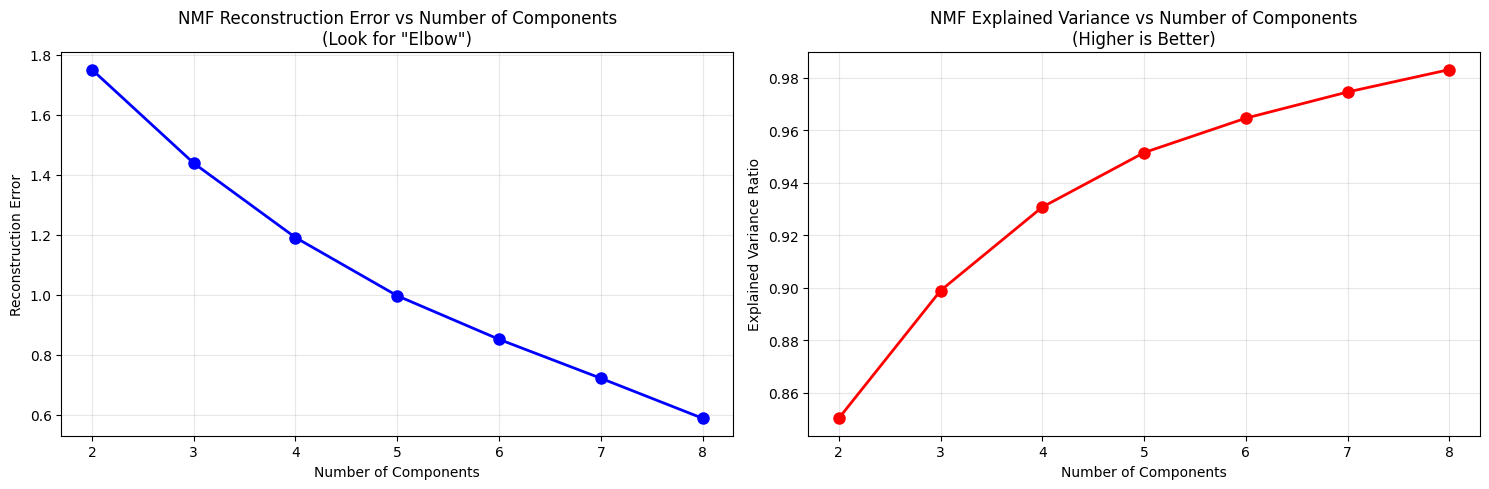


Chosen number of components: 4


In [ ]:
# Plot the results to help choose optimal number of components
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot reconstruction error
ax1.plot(components_range, recon_errors, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Reconstruction Error')
ax1.set_title('NMF Reconstruction Error vs Number of Components\n(Look for "Elbow")')
ax1.grid(True, alpha=0.3)

# Plot explained variance
ax2.plot(components_range, explained_vars, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Explained Variance Ratio')
ax2.set_title('NMF Explained Variance vs Number of Components\n(Higher is Better)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal number of components (look for elbow in reconstruction error)
# For this demo, we'll use 4 components as it provides good balance
optimal_components = 4
print(f"\nChosen number of components: {optimal_components}")

### How to Choose the Right Number of Components?

- **Elbow method**: Look for the "elbow" in the reconstruction error curve
- **Explained variance**: Balance between model complexity and variance explained
- **Business logic**: Consider how many personas are manageable for your content strategy
- **Interpretability**: Ensure each persona is distinct and actionable


<a name="nmf-application"></a>

## 6. Apply NMF for Persona Segmentation

Now we'll apply NMF with our chosen number of components to discover the hidden audience personas.

In [ ]:
print("5. APPLYING NMF FOR PERSONA SEGMENTATION")
print("-" * 45)

# Apply NMF with optimal number of components
nmf_model = NMF(n_components=optimal_components, random_state=42, max_iter=1000)

# Fit the model and get the factorized matrices
W = nmf_model.fit_transform(data_scaled)  # Shape: (demographics, components)
H = nmf_model.components_  # Shape: (components, content_categories)

print(f"NMF Factorization completed!")
print(f"W matrix (demographic loadings) shape: {W.shape}")
print(f"H matrix (content patterns) shape: {H.shape}")
print(f"Reconstruction error: {nmf_model.reconstruction_err_:.3f}")


5. APPLYING NMF FOR PERSONA SEGMENTATION
---------------------------------------------
NMF Factorization completed!
W matrix (demographic loadings) shape: (16, 4)
H matrix (content patterns) shape: (4, 16)
Reconstruction error: 1.190


In [ ]:
# Create DataFrames for better interpretation
W_df = pd.DataFrame(W,
                   index=youtube_data.index,
                   columns=[f'Persona_{i+1}' for i in range(optimal_components)])

H_df = pd.DataFrame(H,
                   index=[f'Persona_{i+1}' for i in range(optimal_components)],
                   columns=youtube_data.columns)

print("Demographic loadings on each persona (W matrix):")
display(W_df.round(3))

print("\nContent patterns for each persona (H matrix):")
display(H_df.round(3))

Demographic loadings on each persona (W matrix):


,Persona_1,Persona_2,Persona_3,Persona_4
Gen_Z_Urban_Male,0.422,0.197,0.356,0.052
Gen_Z_Urban_Female,0.356,0.128,0.344,0.001
Gen_Z_Rural_Male,0.355,0.127,0.409,0.007
Gen_Z_Rural_Female,0.243,0.069,0.137,0.023
Millennial_Urban_Male,0.084,0.562,0.246,0.000
Millennial_Urban_Female,0.000,0.302,0.693,0.375
Millennial_Rural_Male,0.062,0.559,0.155,0.179
Millennial_Rural_Female,0.035,0.226,0.309,0.224
Gen_X_Urban_Male,0.304,0.046,0.389,0.374
Gen_X_Urban_Female,0.442,0.247,0.106,0.701



Content patterns for each persona (H matrix):


,Gaming_Streams,Tech_Reviews,Beauty_Fashion,Cooking_Food,Fitness_Health,Music_Entertainment,News_Politics,Travel_Vlogs,DIY_Crafts,Education_Tutorials,Comedy_Sketches,Sports_Highlights,Pet_Animals,Business_Finance,Art_Design,Parenting_Family
Persona_1,0.885,0.000,0.307,0.000,0.122,1.828,0.580,0.814,0.412,0.888,1.208,0.691,0.583,0.000,0.669,0.487
Persona_2,0.101,1.644,0.373,0.159,0.665,0.100,0.000,0.276,0.000,0.547,0.000,0.436,0.269,1.328,0.466,0.130
Persona_3,0.000,0.000,1.205,0.683,0.633,0.146,0.046,0.244,0.614,0.275,0.068,0.081,0.198,0.453,0.390,0.144
Persona_4,0.340,0.137,0.544,0.823,0.549,0.000,0.581,0.352,0.617,0.270,0.144,0.417,0.406,0.451,0.415,0.542


### Understanding the NMF Output

- **W Matrix**: Shows how much each demographic group belongs to each persona
- **H Matrix**: Shows the content preferences that define each persona
- **Higher values**: Indicate stronger associations or preferences

<a name="analysis"></a>
## 7. Analyze and Interpret the Personas

Let's dive deep into what each persona represents by analyzing the top demographics and content preferences.

In [ ]:
def analyze_personas(W_df, H_df, top_n=5):
    """
    Analyze the personas discovered by NMF by identifying:
    1. Which demographics are most associated with each persona
    2. Which content types define each persona
    """

    personas_analysis = {}

    for persona in W_df.columns:
        print(f"\n=== {persona.upper()} ANALYSIS ===")

        # Top demographics for this persona
        top_demographics = W_df[persona].nlargest(top_n)
        print(f"Top demographics (highest loadings):")
        for demo, loading in top_demographics.items():
            print(f"  {demo}: {loading:.3f}")

        # Top content categories for this persona
        persona_idx = int(persona.split('_')[1]) - 1
        top_content = H_df.iloc[persona_idx].nlargest(top_n)
        print(f"Top content preferences:")
        for content, preference in top_content.items():
            print(f"  {content}: {preference:.3f}")

        # Store for later use
        personas_analysis[persona] = {
            'top_demographics': top_demographics,
            'top_content': top_content
        }

    return personas_analysis

In [ ]:
print("6. PERSONA ANALYSIS AND INTERPRETATION")
print("-" * 42)

# Analyze the personas
persona_analysis = analyze_personas(W_df, H_df)

6. PERSONA ANALYSIS AND INTERPRETATION
------------------------------------------

=== PERSONA_1 ANALYSIS ===
Top demographics (highest loadings):
  Gen_X_Rural_Female: 0.587
  Gen_X_Urban_Female: 0.442
  Gen_X_Rural_Male: 0.425
  Gen_Z_Urban_Male: 0.422
  Gen_Z_Urban_Female: 0.356
Top content preferences:
  Music_Entertainment: 1.828
  Comedy_Sketches: 1.208
  Education_Tutorials: 0.888
  Gaming_Streams: 0.885
  Travel_Vlogs: 0.814

=== PERSONA_2 ANALYSIS ===
Top demographics (highest loadings):
  Millennial_Urban_Male: 0.562
  Millennial_Rural_Male: 0.559
  Millennial_Urban_Female: 0.302
  Gen_X_Rural_Female: 0.264
  Gen_X_Urban_Female: 0.247
Top content preferences:
  Tech_Reviews: 1.644
  Business_Finance: 1.328
  Fitness_Health: 0.665
  Education_Tutorials: 0.547
  Art_Design: 0.466

=== PERSONA_3 ANALYSIS ===
Top demographics (highest loadings):
  Millennial_Urban_Female: 0.693
  Boomer_Rural_Female: 0.499
  Gen_Z_Rural_Male: 0.409
  Gen_X_Urban_Male: 0.389
  Gen_Z_Urban_Male: 0.

<a name="visualization"></a>

## 8. Visualize the Personas

Visual representation helps us better understand and communicate the personas to stakeholders.


7. PERSONA VISUALIZATION
-------------------------


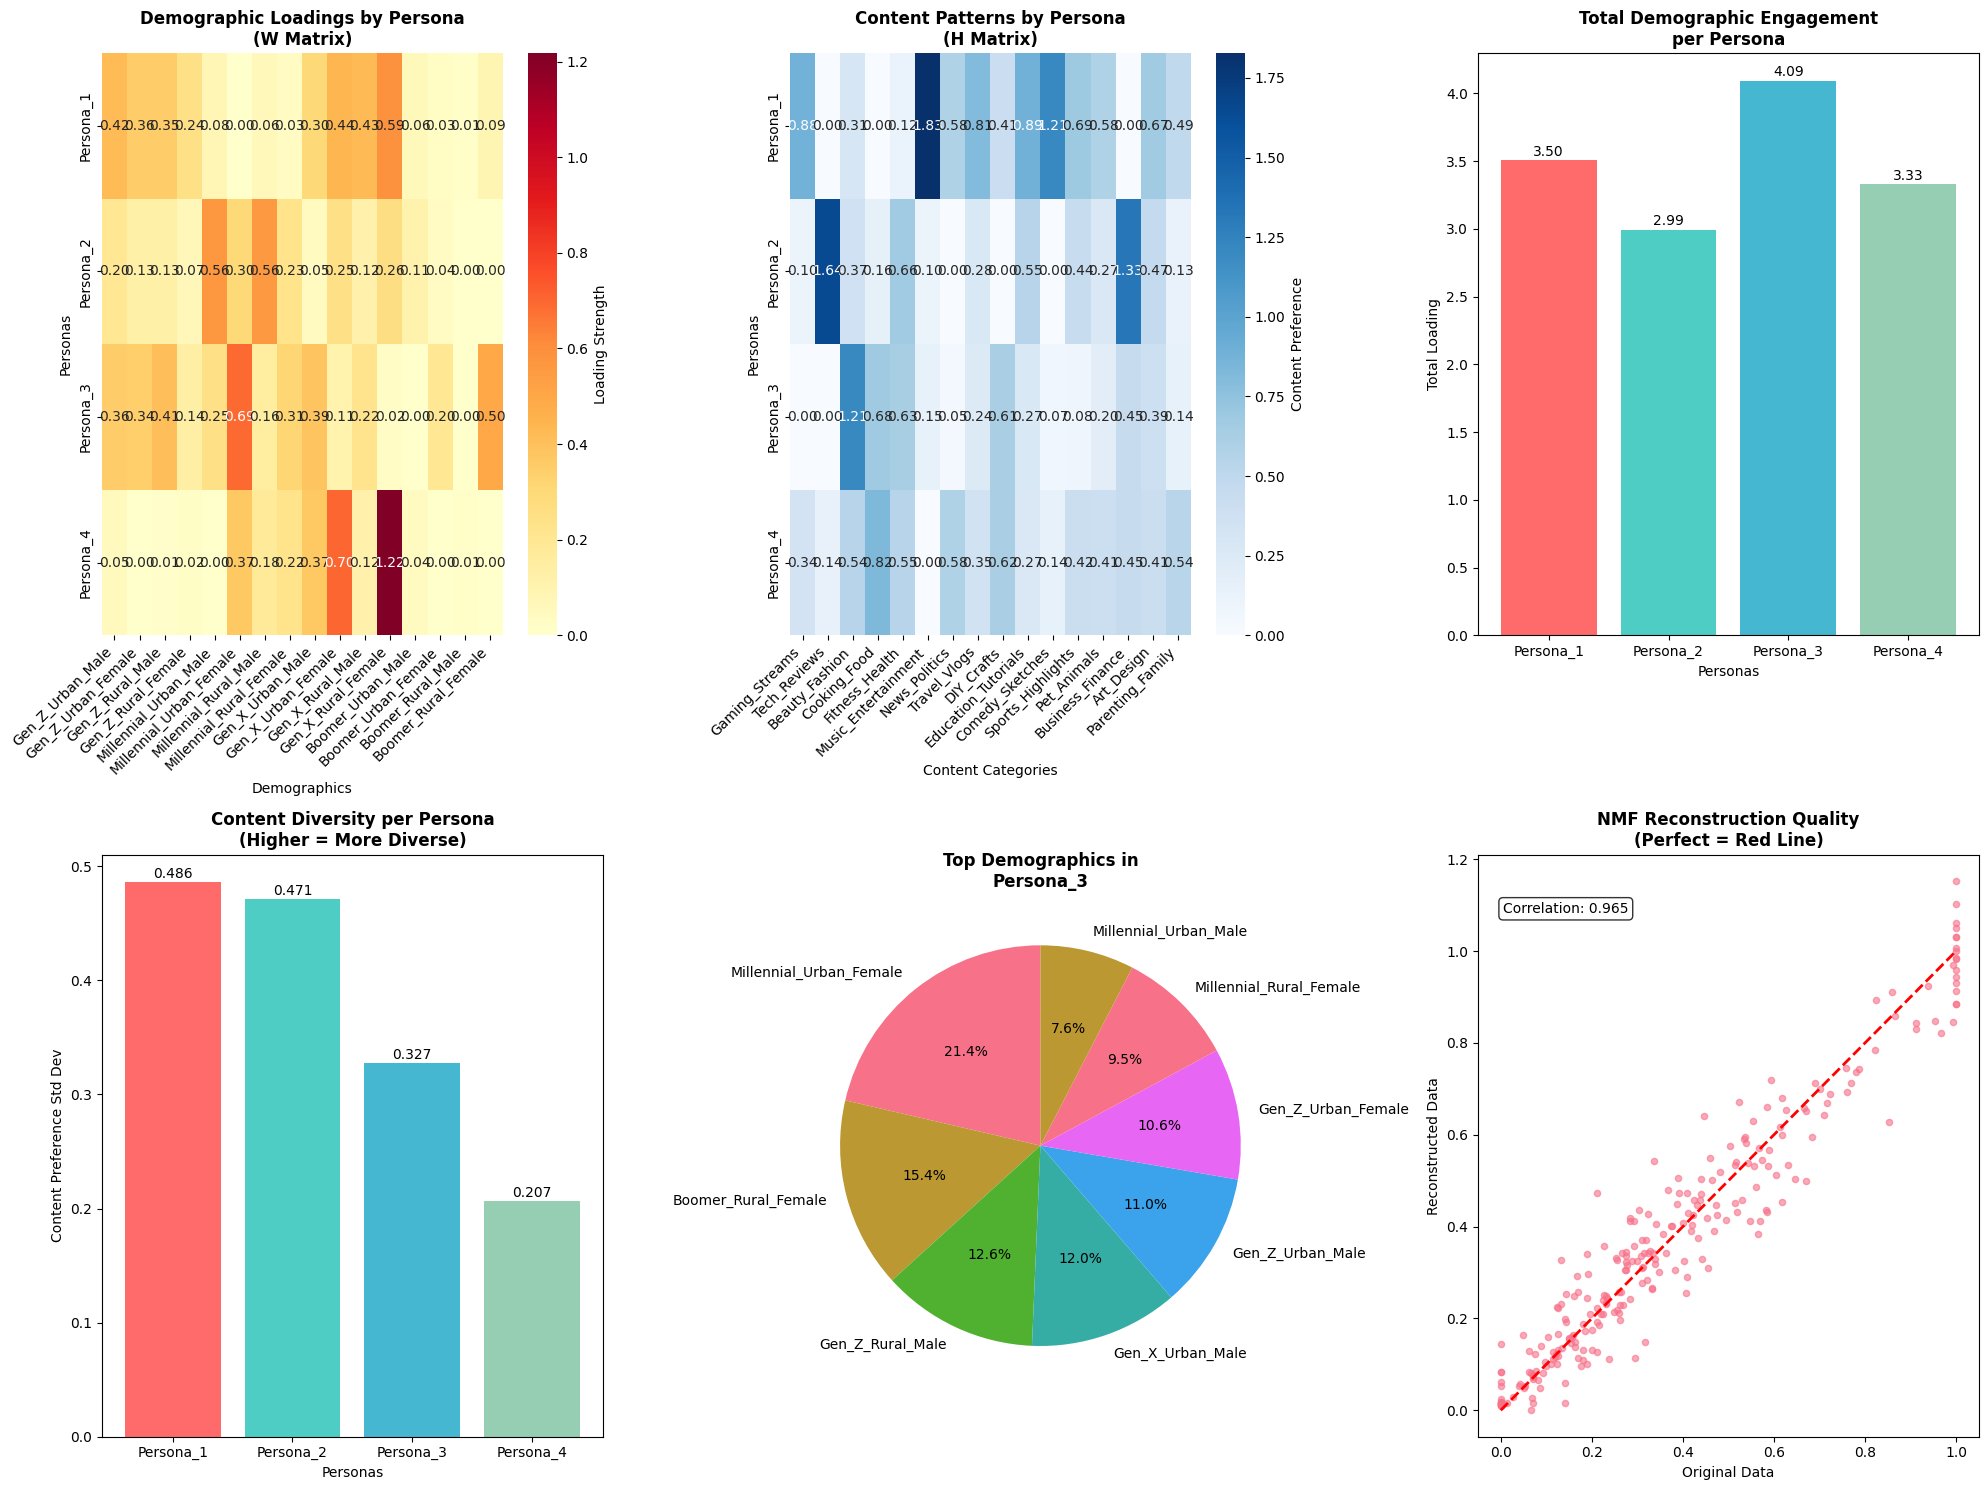

In [ ]:
print("7. PERSONA VISUALIZATION")
print("-" * 25)

# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 15))

# 1. Heatmap of demographic loadings (W matrix)
plt.subplot(2, 3, 1)
sns.heatmap(W_df.T, annot=True, cmap='YlOrRd', fmt='.2f', cbar_kws={'label': 'Loading Strength'})
plt.title('Demographic Loadings by Persona\n(W Matrix)', fontsize=12, fontweight='bold')
plt.ylabel('Personas')
plt.xlabel('Demographics')
plt.xticks(rotation=45, ha='right')

# 2. Heatmap of content patterns (H matrix)
plt.subplot(2, 3, 2)
sns.heatmap(H_df, annot=True, cmap='Blues', fmt='.2f', cbar_kws={'label': 'Content Preference'})
plt.title('Content Patterns by Persona\n(H Matrix)', fontsize=12, fontweight='bold')
plt.ylabel('Personas')
plt.xlabel('Content Categories')
plt.xticks(rotation=45, ha='right')

# 3. Bar plot of total engagement per persona
plt.subplot(2, 3, 3)
persona_total_engagement = W_df.sum(axis=0)
bars = plt.bar(persona_total_engagement.index, persona_total_engagement.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Total Demographic Engagement\nper Persona', fontsize=12, fontweight='bold')
plt.ylabel('Total Loading')
plt.xlabel('Personas')
for bar, value in zip(bars, persona_total_engagement.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.2f}', ha='center', va='bottom')

# 4. Content diversity per persona
plt.subplot(2, 3, 4)
content_diversity = H_df.std(axis=1)  # Standard deviation as measure of diversity
bars = plt.bar(content_diversity.index, content_diversity.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Content Diversity per Persona\n(Higher = More Diverse)', fontsize=12, fontweight='bold')
plt.ylabel('Content Preference Std Dev')
plt.xlabel('Personas')
for bar, value in zip(bars, content_diversity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.3f}', ha='center', va='bottom')

# 5. Demographic composition of strongest persona
plt.subplot(2, 3, 5)
strongest_persona = W_df.sum(axis=0).idxmax()
strongest_persona_demographics = W_df[strongest_persona].nlargest(8)
plt.pie(strongest_persona_demographics.values, labels=strongest_persona_demographics.index,
        autopct='%1.1f%%', startangle=90)
plt.title(f'Top Demographics in\n{strongest_persona}', fontsize=12, fontweight='bold')

# 6. Reconstruction quality visualization
plt.subplot(2, 3, 6)
original_data_flat = data_scaled.flatten()
reconstructed_data = np.dot(W, H).flatten()
plt.scatter(original_data_flat, reconstructed_data, alpha=0.6, s=20)
plt.plot([0, 1], [0, 1], 'r--', lw=2)
plt.xlabel('Original Data')
plt.ylabel('Reconstructed Data')
plt.title('NMF Reconstruction Quality\n(Perfect = Red Line)', fontsize=12, fontweight='bold')
correlation = np.corrcoef(original_data_flat, reconstructed_data)[0, 1]
plt.text(0.05, 0.9, f'Correlation: {correlation:.3f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

<a name="validation"></a>

## 9. Validate the Segmentation

Before implementing our personas, we need to validate that our segmentation is meaningful and robust.


In [ ]:
def validate_nmf_segmentation(W_df, original_data):
    """
    Validate the NMF segmentation using multiple metrics.
    """

    print("Validation Metrics:")
    print("-" * 18)

    # 1. Assign each demographic to its dominant persona
    dominant_personas = W_df.idxmax(axis=1)
    print("Demographic assignments to dominant personas:")
    for demo, persona in dominant_personas.items():
        max_loading = W_df.loc[demo, persona]
        print(f"  {demo} -> {persona} (loading: {max_loading:.3f})")

    # 2. Calculate silhouette score for the segmentation
    # Use the persona loadings as features for clustering validation
    persona_assignments = [int(persona.split('_')[1]) - 1 for persona in dominant_personas]

    if len(set(persona_assignments)) > 1:  # Need at least 2 different clusters
        silhouette_avg = silhouette_score(W_df.values, persona_assignments)
        print(f"\nSilhouette Score: {silhouette_avg:.3f}")
        print("(Range: -1 to 1, higher is better. >0.5 is good, >0.7 is excellent)")

    # 3. Calculate explained variance by the NMF model
    reconstructed = np.dot(W_df.values, H_df.values)

    # Transform back to original scale for comparison
    original_scaled = scaler.transform(original_data)
    total_variance = np.var(original_scaled)
    residual_variance = np.var(original_scaled - reconstructed)
    explained_variance_ratio = 1 - (residual_variance / total_variance)

    print(f"\nExplained Variance Ratio: {explained_variance_ratio:.3f}")
    print("(Higher is better. >0.7 indicates good model fit)")

    # 4. Check for persona distinctiveness
    print(f"\nPersona Distinctiveness Analysis:")
    persona_correlations = H_df.T.corr()

    # Calculate average correlation between personas (lower is better for distinctiveness)
    off_diagonal_correlations = []
    for i in range(len(H_df)):
        for j in range(i+1, len(H_df)):
            off_diagonal_correlations.append(persona_correlations.iloc[i, j])

    avg_inter_persona_correlation = np.mean(off_diagonal_correlations)
    print(f"Average inter-persona correlation: {avg_inter_persona_correlation:.3f}")
    print("(Lower values indicate more distinct personas)")

    return {
        'dominant_personas': dominant_personas,
        'silhouette_score': silhouette_avg if len(set(persona_assignments)) > 1 else None,
        'explained_variance': explained_variance_ratio,
        'inter_persona_correlation': avg_inter_persona_correlation
    }

In [ ]:
print("8. SEGMENTATION VALIDATION")
print("-" * 28)

# Validate the segmentation
validation_results = validate_nmf_segmentation(W_df, youtube_data)

8. SEGMENTATION VALIDATION
----------------------------
Validation Metrics:
------------------
Demographic assignments to dominant personas:
  Gen_Z_Urban_Male -> Persona_1 (loading: 0.422)
  Gen_Z_Urban_Female -> Persona_1 (loading: 0.356)
  Gen_Z_Rural_Male -> Persona_3 (loading: 0.409)
  Gen_Z_Rural_Female -> Persona_1 (loading: 0.243)
  Millennial_Urban_Male -> Persona_2 (loading: 0.562)
  Millennial_Urban_Female -> Persona_3 (loading: 0.693)
  Millennial_Rural_Male -> Persona_2 (loading: 0.559)
  Millennial_Rural_Female -> Persona_3 (loading: 0.309)
  Gen_X_Urban_Male -> Persona_3 (loading: 0.389)
  Gen_X_Urban_Female -> Persona_4 (loading: 0.701)
  Gen_X_Rural_Male -> Persona_1 (loading: 0.425)
  Gen_X_Rural_Female -> Persona_4 (loading: 1.218)
  Boomer_Urban_Male -> Persona_2 (loading: 0.111)
  Boomer_Urban_Female -> Persona_3 (loading: 0.202)
  Boomer_Rural_Male -> Persona_4 (loading: 0.014)
  Boomer_Rural_Female -> Persona_3 (loading: 0.499)

Silhouette Score: 0.094
(Range: -1

### Validation Metrics Explained

- **Silhouette Score**: Measures how well-separated the clusters are (-1 to 1, higher is better)
- **Explained Variance**: Proportion of data variance captured by the model (0 to 1, higher is better)
- **Inter-persona Correlation**: How similar personas are to each other (lower means more distinct)


<a name="actionable"></a>
## 10. Create Actionable Personas

The final step is converting our mathematical results into actionable marketing personas with concrete strategies.

In [ ]:
def create_actionable_personas(W_df, H_df, validation_results):
    """
    Create detailed, actionable personas based on the NMF results.
    """

    personas = {}

    for i, persona_name in enumerate(W_df.columns):
        print(f"\n{'='*60}")
        print(f"PERSONA {i+1}: {persona_name.upper()}")
        print(f"{'='*60}")

        # Get top demographics and content for this persona
        top_demographics = W_df[persona_name].nlargest(3)
        top_content = H_df.iloc[i].nlargest(5)

        # Analyze demographic characteristics
        demo_characteristics = []
        for demo in top_demographics.index:
            parts = demo.split('_')
            age_group = parts[0]
            if len(parts) > 1 and parts[1] == 'Z':
                age_group = 'Gen_Z'
            location = parts[1] if age_group != 'Gen_Z' else parts[2]
            gender = parts[2] if age_group != 'Gen_Z' else parts[3]
            demo_characteristics.append((age_group, location, gender))

        # Determine primary characteristics
        age_groups = [char[0] for char in demo_characteristics]
        locations = [char[1] for char in demo_characteristics]
        genders = [char[2] for char in demo_characteristics]

        primary_age = max(set(age_groups), key=age_groups.count) if age_groups else 'Unknown'
        primary_location = max(set(locations), key=locations.count) if locations else 'Unknown'
        primary_gender = max(set(genders), key=genders.count) if genders else 'Unknown'

        # Generate persona description
        print(f"PRIMARY CHARACTERISTICS:")
        print(f"  Age Group: {primary_age}")
        print(f"  Location: {primary_location}")
        print(f"  Gender: {primary_gender}")

        print(f"\nTOP DEMOGRAPHICS (with engagement strength):")
        for demo, strength in top_demographics.items():
            print(f"  {demo.replace('_', ' ')}: {strength:.3f}")

        print(f"\nCONTENT PREFERENCES (normalized preference scores):")
        for content, preference in top_content.items():
            print(f"  {content.replace('_', ' ')}: {preference:.3f}")

        # Calculate average viewing time for this persona
        avg_viewing_time = top_content.mean()

        # Generate content strategy recommendations
        print(f"\nCONTENT STRATEGY RECOMMENDATIONS:")

        content_categories = list(top_content.index)

        if any('Gaming' in cat or 'Tech' in cat for cat in content_categories):
            print(f"  • Focus on technology and gaming content")
            print(f"  • Use latest tech trends and gaming terminology")
            print(f"  • Consider live streaming and interactive content")

        if any('Beauty' in cat or 'Fashion' in cat for cat in content_categories):
            print(f"  • Emphasize visual aesthetics and style content")
            print(f"  • Partner with beauty/fashion influencers")
            print(f"  • Use high-quality visual production")

        if any('Cooking' in cat or 'Food' in cat for cat in content_categories):
            print(f"  • Create recipe and cooking tutorial content")
            print(f"  • Focus on easy-to-follow, practical content")
            print(f"  • Consider seasonal and trending food topics")

        if any('News' in cat or 'Politics' in cat for cat in content_categories):
            print(f"  • Provide informative, balanced content")
            print(f"  • Focus on credible sources and fact-checking")
            print(f"  • Create explainer-style videos")

        # Engagement recommendations
        print(f"\nENGAGEMENT RECOMMENDATIONS:")
        print(f"  • Target video length: {avg_viewing_time*10:.0f}-{avg_viewing_time*15:.0f} minutes")

        if primary_age == 'Gen_Z':
            print(f"  • Use trendy music and fast-paced editing")
            print(f"  • Incorporate memes and pop culture references")
            print(f"  • Optimize for mobile viewing")
        elif primary_age == 'Millennial':
            print(f"  • Focus on practical, career-oriented content")
            print(f"  • Use professional but approachable tone")
            print(f"  • Include actionable takeaways")
        elif primary_age in ['Gen_X', 'Boomer']:
            print(f"  • Use clear, straightforward presentation")
            print(f"  • Provide detailed explanations")
            print(f"  • Focus on value and practical benefits")

        # Timing recommendations
        print(f"\nPOSTING TIME RECOMMENDATIONS:")
        if primary_age in ['Gen_Z', 'Millennial']:
            print(f"  • Post during evening hours (6-9 PM)")
            print(f"  • Consider weekend morning posts")
        else:
            print(f"  • Post during daytime hours (10 AM - 2 PM)")
            print(f"  • Weekday posts may perform better")

        # Store persona data
        personas[persona_name] = {
            'primary_age': primary_age,
            'primary_location': primary_location,
            'primary_gender': primary_gender,
            'top_demographics': top_demographics,
            'top_content': top_content,
            'avg_preference_score': avg_viewing_time
        }

    return personas

In [ ]:
print("9. CREATING ACTIONABLE PERSONAS")
print("-" * 35)

# Create actionable personas
actionable_personas = create_actionable_personas(W_df, H_df, validation_results)

9. CREATING ACTIONABLE PERSONAS
-----------------------------------

PERSONA 1: PERSONA_1
PRIMARY CHARACTERISTICS:
  Age Group: Gen
  Location: X
  Gender: Rural

TOP DEMOGRAPHICS (with engagement strength):
  Gen X Rural Female: 0.587
  Gen X Urban Female: 0.442
  Gen X Rural Male: 0.425

CONTENT PREFERENCES (normalized preference scores):
  Music Entertainment: 1.828
  Comedy Sketches: 1.208
  Education Tutorials: 0.888
  Gaming Streams: 0.885
  Travel Vlogs: 0.814

CONTENT STRATEGY RECOMMENDATIONS:
  • Focus on technology and gaming content
  • Use latest tech trends and gaming terminology
  • Consider live streaming and interactive content

ENGAGEMENT RECOMMENDATIONS:
  • Target video length: 11-17 minutes

POSTING TIME RECOMMENDATIONS:
  • Post during daytime hours (10 AM - 2 PM)
  • Weekday posts may perform better

PERSONA 2: PERSONA_2
PRIMARY CHARACTERISTICS:
  Age Group: Millennial
  Location: Urban
  Gender: Male

TOP DEMOGRAPHICS (with engagement strength):
  Millennial Urba

### Persona Summary Table

Let's create a quick reference table of our discovered personas:

In [ ]:
# Create a summary DataFrame of personas
persona_summary = []

for persona_name, persona_data in actionable_personas.items():
    summary = {
        'Persona': persona_name,
        'Primary_Age': persona_data['primary_age'],
        'Primary_Location': persona_data['primary_location'],
        'Primary_Gender': persona_data['primary_gender'],
        'Top_Content_1': persona_data['top_content'].index[0],
        'Top_Content_2': persona_data['top_content'].index[1],
        'Avg_Preference_Score': persona_data['avg_preference_score']
    }
    persona_summary.append(summary)

persona_summary_df = pd.DataFrame(persona_summary)
print("PERSONA SUMMARY TABLE:")
display(persona_summary_df)

PERSONA SUMMARY TABLE:


,Persona,Primary_Age,Primary_Location,Primary_Gender,Top_Content_1,Top_Content_2,Avg_Preference_Score
0,Persona_1,Gen,X,Rural,Music_Entertainment,Comedy_Sketches,1.124364
1,Persona_2,Millennial,Urban,Male,Tech_Reviews,Business_Finance,0.930098
2,Persona_3,Gen_Z,Rural,Female,Beauty_Fashion,Cooking_Food,0.717628
3,Persona_4,Gen,X,Urban,Cooking_Food,DIY_Crafts,0.622946


<a name="summary"></a>
## 11. Summary and Next Steps

### Model Performance Summary

In [ ]:
print(f"\n{'='*70}")
print("SUMMARY AND NEXT STEPS")
print(f"{'='*70}")

print(f"\nMODEL PERFORMANCE SUMMARY:")
print(f"  • Number of personas discovered: {optimal_components}")
print(f"  • Explained variance: {validation_results['explained_variance']:.1%}")
if validation_results['silhouette_score']:
    print(f"  • Silhouette score: {validation_results['silhouette_score']:.3f}")
print(f"  • Inter-persona correlation: {validation_results['inter_persona_correlation']:.3f}")

print(f"\nKEY INSIGHTS:")
print(f"  • Successfully segmented {len(youtube_data)} demographic groups into {optimal_components} distinct personas")
print(f"  • Each persona shows unique content preferences and demographic composition")
print(f"  • The segmentation captures {validation_results['explained_variance']:.1%} of the variance in viewing behavior")


SUMMARY AND NEXT STEPS

MODEL PERFORMANCE SUMMARY:
  • Number of personas discovered: 4
  • Explained variance: 93.1%
  • Silhouette score: 0.094
  • Inter-persona correlation: -0.217

KEY INSIGHTS:
  • Successfully segmented 16 demographic groups into 4 distinct personas
  • Each persona shows unique content preferences and demographic composition
  • The segmentation captures 93.1% of the variance in viewing behavior


### Implementation Roadmap


In [ ]:
print(f"\nNEXT STEPS FOR IMPLEMENTATION:")
print(f"  1. Validate personas with real user data and feedback")
print(f"  2. Create targeted content for each persona")
print(f"  3. A/B test content strategies for different personas")
print(f"  4. Monitor persona performance and adjust strategies")
print(f"  5. Regularly re-run NMF analysis with new data to update personas")

print(f"\nTECHNICAL CONSIDERATIONS:")
print(f"  • NMF assumes non-negative relationships (suitable for viewing time data)")
print(f"  • Model can be updated incrementally as new data becomes available")
print(f"  • Consider ensemble methods with other clustering techniques for validation")
print(f"  • Monitor for persona drift over time as audience preferences evolve")


NEXT STEPS FOR IMPLEMENTATION:
  1. Validate personas with real user data and feedback
  2. Create targeted content for each persona
  3. A/B test content strategies for different personas
  4. Monitor persona performance and adjust strategies
  5. Regularly re-run NMF analysis with new data to update personas

TECHNICAL CONSIDERATIONS:
  • NMF assumes non-negative relationships (suitable for viewing time data)
  • Model can be updated incrementally as new data becomes available
  • Consider ensemble methods with other clustering techniques for validation
  • Monitor for persona drift over time as audience preferences evolve


### Advanced Extensions

Here are some ways to extend this analysis:

In [ ]:
print(f"\nADVANCED EXTENSIONS TO CONSIDER:")
print(f"  • Temporal Analysis: Track how personas evolve over time")
print(f"  • Geographic Segmentation: Include location-specific data")
print(f"  • Behavioral Metrics: Incorporate engagement rates, comments, shares")
print(f"  • Content Performance: Map content success to specific personas")
print(f"  • Predictive Modeling: Forecast content performance for each persona")
print(f"  • Real-time Updates: Implement streaming NMF for live persona updates")


ADVANCED EXTENSIONS TO CONSIDER:
  • Temporal Analysis: Track how personas evolve over time
  • Geographic Segmentation: Include location-specific data
  • Behavioral Metrics: Incorporate engagement rates, comments, shares
  • Content Performance: Map content success to specific personas
  • Predictive Modeling: Forecast content performance for each persona
  • Real-time Updates: Implement streaming NMF for live persona updates


## Conclusion

This notebook demonstrated how Non-negative Matrix Factorization can be effectively used for YouTube audience persona generation. The key advantages of NMF for this application include:

### **Why NMF Works Well for Audience Segmentation:**

1. **Non-negativity Constraint**: Perfect for engagement metrics (viewing time, clicks, etc.)
2. **Interpretability**: Both factor matrices have clear business meaning
3. **Dimensionality Reduction**: Reduces complex audience data into manageable personas
4. **Flexibility**: Can handle various data types and scales well

### **Key Takeaways:**

- **Data Quality Matters**: Realistic, representative data is crucial for meaningful personas
- **Validation is Essential**: Use multiple metrics to ensure robust segmentation
- **Actionability**: Convert mathematical results into concrete business strategies
- **Iteration**: Regularly update personas as audience preferences evolve

### **Business Impact:**

By implementing these personas, content creators and marketers can:
- Create more targeted, relevant content
- Optimize posting schedules for different audience segments  
- Improve content strategy ROI through better audience understanding
- Make data-driven decisions about content direction

The personas discovered through this NMF analysis provide a foundation for more effective YouTube content strategy, enabling creators to deliver the right content to the right audience at the right time.

In [ ]:
print(f"\n{'='*70}")
print("PERSONA GENERATION COMPLETE!")
print(f"{'='*70}")


PERSONA GENERATION COMPLETE!


---

**Note**: This notebook uses synthetic data for demonstration purposes. In a real-world application, you would use actual YouTube Analytics data, viewer engagement metrics, and demographic information to generate more accurate and actionable personas.